# Lab08 - Bài tập

### Bài 1

Nghiên cứu mức thu nhập ($X$) và chi tiêu ($Y$) trong một tháng của một công ty. Khảo sát ngẫu nhiên 7 nhân viên, ta thu được bảng số liệu sau:

| X            | 130     | 150      | 133      | 170      | 170      | 210      | 230      |
| :----------: | :-----: | :------: | :------: | :------: | :------: | :------: | :------: |
| **Y**        | **84**  | **120**  | **108**  | **130**  | **130**  | **150**  | **160**  |


a. Dựa vào bảng dữ liệu trên cho biết có xây dựng được mô hình hồi quy hay không? Nếu có hãy xây dựng mô hình hồi quy để ước tính chi tiêu dựa theo thu nhập

b. Dự đoán mức chi tiêu của nhân viên công ty trên nếu biết thu nhập là 200$

In [33]:
import numpy as np 
import matplotlib.pyplot as plt

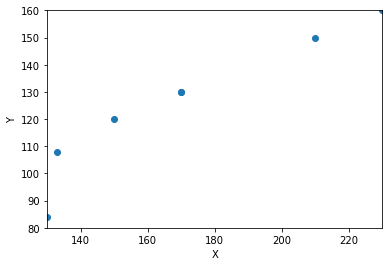

In [34]:
#a)
#Ta có dữ liệu x và y theo đề bài
x = np.array([130,150,133,170,170,210,230])
y = np.array([84,120,108,130,130,150,160])
# Vẽ đồ thị xem mối tương quan giữa 2 biến
plt.plot(x, y, 'o')
plt.axis([130, 230, 80, 160])
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [35]:
#Tính hệ số tương quan giữa 2 biến
np.corrcoef(x, y)

array([[1.        , 0.94705241],
       [0.94705241, 1.        ]])

Ta thấy hệ số tương quan là: __0.947__ cho thấy 2 biến x, y có tương quan tuyến tính mạnh. Vì vậy, có thể xây dựng mô hình hồi quy tuyến tính cho 2 biến x, y

Xây dựng mô hình hồi quy

In [36]:
import statsmodels.api as sm
import pandas as pd

In [37]:
#Xây dựng mô hình hồi quy bằng thư viện
model = sm.formula.ols('y~x', data=pd.DataFrame({'x': x, 'y':y})).fit()
print(f"Mô hình hồi quy: y = {model.params[0].round(4)} + {model.params[1].round(4)}x")

Mô hình hồi quy: y = 17.2706 + 0.638x


Dự đoán

In [38]:
#Dự đoán mức chi tiêu khi mức thu nhập là 300
model.predict(exog=dict(x=300))

0    208.663521
dtype: float64

### Bài 2

Tiến hành nghiên cứu mối quan hệ giữa:

- X: giá bán kẻ của thịt gà (nghìn/kg) 
- Y: lượng thịt gà tiêu thụ (kg/tháng)

Dữ liệu thu được gồm 10 tháng như sau:

| X            | 35       | 40       | 45       | 40       | 38       | 40       | 45       | 30       | 42       | 38       |
| :----------: | :------: | :------: | :------: | :------: | :------: | :------: | :------: | :------: | :------: | :------: |
| **Y**        | **2.29** | **2.04** | **0.59** | **2.06** | **2.50** | **2.32** | **1.57** | **3.96** | **1.43** | **2.34** |


a. Dựa vào bảng dữ liệu trên cho biết có xây dựng được mô hình hồi quy hay không? Nếu có hãy xây dựng mô hình hồi quy để ước tính lượng tiêu thụ thịt gà theo giá bán.

b. Dự đoán lượng tiêu thụ khi giá bán lẻ là 41(nghìn/tháng)

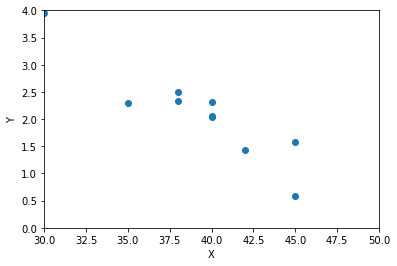

In [39]:
#a) 
#Ta có dữ liệu x và y theo đề bài
x = np.array([35,40,45,40,38,40,45,30,42,38])
y = np.array([2.29,2.04,0.59,2.06,2.50,2.32,1.57, 3.96, 1.43, 2.34])
# Vẽ đồ thị để xem tương quan giữa 2 biến
plt.plot(x, y, 'o')
plt.axis([30, 50, 0., 4.])
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [40]:
#Tính hệ số tương quan giữa 2 biến
np.corrcoef(x, y)

array([[ 1.        , -0.91953287],
       [-0.91953287,  1.        ]])

Ta thấy hệ số tương quan là: __-0.919__ cho thấy 2 biến x, y có tương quan tuyến tính mạnh. Vì vậy, có thể xây dựng mô hình hồi quy tuyến tính cho 2 biến x, y

Xây dựng mô hình hồi quy

In [41]:
#Xây dựng mô hình hồi quy
model = sm.formula.ols('y~x', data=pd.DataFrame({'x': x, 'y':y})).fit()
print(f"Mô hình hồi quy: y = {model.params[0].round(4)} + {model.params[1].round(4)}x")

Mô hình hồi quy: y = 9.0808 + -0.1774x


Dự báo

In [42]:
#Dự báo lượng tiêu thụ khi giá bán là 41
model.predict(exog=dict(x=41))

0    1.808462
dtype: float64

## Bài 3

Dụa trên file dữ liệu `Advertising.csv` bạn hãy dự đoán doanh số bán hàng (`sales`) dựa trên số tiền chi cho các nền tảng tiếp thị khác nhau như `TV`, `Radio` và `Newspaper`

a. Đọc file dữ liệu cho biết các thông tin cơ bản về dữ liệu: kích thước, dữ liệu có giá trị trống hay không, hiện các giá trị thống kê cơ bản của các thuộc tính.

b. Để dự đoán doanh số bằng phương pháp hồi quy tuyến tính đơn giản (Simple Linear Regression) trước tiên cần lựa chọn một trong các thuộc tính còn lại. Theo bạn thuộc tính nào phù hợp để xây dựng mô hình hồi quy. Giải thích và minh họa bằng 2 cách

c. Xây dụng phương trình hồi quy, trực quan mô hình (đường thẳng) tìm được. Theo bạn để đánh giá mô hình trên cần dùng đại lượng nào?

In [43]:
#Đọc file dữ liệu
df = pd.read_csv("./Advertising.csv")

df

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [44]:
#Kích thước dữ liệu
df.shape

(200, 5)

In [45]:
#Tổng số hàng không có dữ liệu (null)
df.isnull().sum()

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

In [46]:
#Thống kê cơ bản các dữ liệu
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [47]:
# Tính toán ma trận tương quan giữa các biến
correlation_matrix = df.corr()

# Hiển thị ma trận tương quan
print("\nMa trận tương quan:")
print(correlation_matrix)

# Chọn biến có tương quan mạnh nhất với 'Sales'
correlation_sales = correlation_matrix['sales'].sort_values(ascending=False)
print("\nTương quan của các biến với 'Sales':")
print(correlation_sales)



Ma trận tương quan:
            Unnamed: 0        TV     radio  newspaper     sales
Unnamed: 0    1.000000  0.017715 -0.110680  -0.154944 -0.051616
TV            0.017715  1.000000  0.054809   0.056648  0.782224
radio        -0.110680  0.054809  1.000000   0.354104  0.576223
newspaper    -0.154944  0.056648  0.354104   1.000000  0.228299
sales        -0.051616  0.782224  0.576223   0.228299  1.000000

Tương quan của các biến với 'Sales':
sales         1.000000
TV            0.782224
radio         0.576223
newspaper     0.228299
Unnamed: 0   -0.051616
Name: sales, dtype: float64


Ta chọn thuộc tính TV vì hệ số tương quan giữa TV và sale là __0.78__

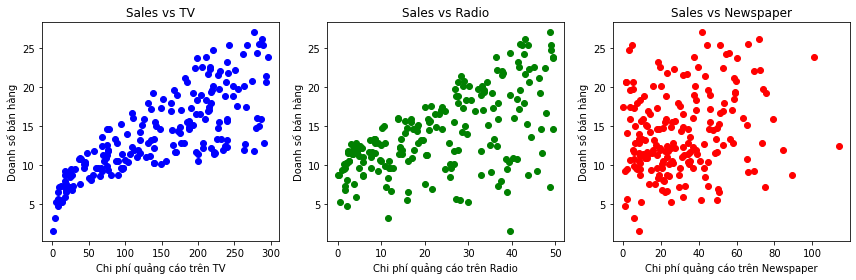

In [48]:
# Vẽ biểu đồ phân tán giữa 'Sales' và 'TV'
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)  # Vị trí biểu đồ (1 dòng, 3 cột, biểu đồ 1)
plt.scatter(df['TV'], df['sales'], color='blue')
plt.title('Sales vs TV')
plt.xlabel('Chi phí quảng cáo trên TV')
plt.ylabel('Doanh số bán hàng')

# Vẽ biểu đồ phân tán giữa 'Sales' và 'Radio'
plt.subplot(1, 3, 2)  # Biểu đồ 2
plt.scatter(df['radio'], df['sales'], color='green')
plt.title('Sales vs Radio')
plt.xlabel('Chi phí quảng cáo trên Radio')
plt.ylabel('Doanh số bán hàng')

# Vẽ biểu đồ phân tán giữa 'Sales' và 'Newspaper'
plt.subplot(1, 3, 3)  # Biểu đồ 3
plt.scatter(df['newspaper'], df['sales'], color='red')
plt.title('Sales vs Newspaper')
plt.xlabel('Chi phí quảng cáo trên Newspaper')
plt.ylabel('Doanh số bán hàng')

# Hiển thị các biểu đồ
plt.tight_layout()
plt.show()

Với 3 đồ thị trên thì mối tương quan của sales với TV là mạnh nhất nên ta chọn TV

In [49]:
#Phương trình hồi quy
model = sm.formula.ols('y~x', data=pd.DataFrame({'x': df['TV'], 'y':df['sales']})).fit()
print(f"Mô hình hồi quy: y = {model.params[0].round(4)} + {model.params[1].round(4)}x")

Mô hình hồi quy: y = 7.0326 + 0.0475x


Đánh giá mô hình

In [50]:
print('Hệ số xác định mô hình: ', model.rsquared)

Hệ số xác định mô hình:  0.611875050850071



Phương trình hồi quy:
Sales = 7.03 + 0.05 * TV


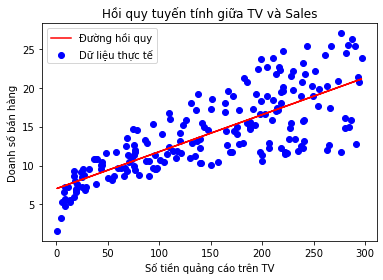

In [51]:
from sklearn.linear_model import LinearRegression
X = df[['TV']]  # Biến độc lập
y = df['sales']
model = LinearRegression()
model.fit(X, y)

# Dự đoán doanh thu bán hàng
y_pred = model.predict(X)


print("\nPhương trình hồi quy:")
print(f"Sales = {model.intercept_:.2f} + {model.coef_[0]:.2f} * TV")

# Vẽ biểu đồ phân tán và đường hồi quy
plt.scatter(X, y, color='blue', label='Dữ liệu thực tế')
plt.plot(X, y_pred, color='red', label='Đường hồi quy')
plt.title('Hồi quy tuyến tính giữa TV và Sales')
plt.xlabel('Số tiền quảng cáo trên TV')
plt.ylabel('Doanh số bán hàng')
plt.legend()
plt.show()

---